In [2]:
import os, re, glob
from pathlib import Path
import pandas as pd

# ====== RUTAS (AJUSTA) ======
images_dir = r"C:\Users\drive\OneDrive\Escritorio\data\datos_raw\messidor\train"  # carpeta con las .png/.tif
pairs_csv  = r"C:\Users\drive\OneDrive\Escritorio\data\datos_raw\messidor\train_original.csv"  # left;right
labels_csv = r"C:\Users\drive\OneDrive\Escritorio\data\datos_raw\messidor\train_completo.csv"   # tu CSV de diagnósticos

# ====== 0) Escanear disco y construir índice por basename ======
ALLOWED_EXTS = (".png", ".tif", ".tiff", ".jpg", ".jpeg")
files = []
for ext in ALLOWED_EXTS:
    files.extend(glob.glob(str(Path(images_dir) / f"**/*{ext}"), recursive=True))

def basename(p):
    return Path(p).stem  # nombre sin extensión

disk_df = pd.DataFrame({
    "filepath": files,
})
disk_df["filename"] = disk_df["filepath"].apply(lambda p: Path(p).name)
disk_df["basename"] = disk_df["filename"].str.replace(r'\.(png|tif|tiff|jpg|jpeg)$','', regex=True, case=False)
disk_df["ext"] = disk_df["filename"].str.extract(r'\.([A-Za-z0-9]+)$')[0].str.lower()

# ====== 1) Cargar pares left/right y limpiar ======
pairs = pd.read_csv(pairs_csv, sep=';', dtype=str)
pairs.columns = pairs.columns.str.strip().str.lower()

# mapear nombres si vienen raros
colmap = {}
for c in pairs.columns:
    if re.search(r'\blef?t\b', c, flags=re.I): colmap[c] = 'left'
    if re.search(r'\bright\b', c, flags=re.I): colmap[c] = 'right'
pairs = pairs.rename(columns=colmap)

# quitar filas basura/encabezados repetidos
pairs = pairs.apply(lambda s: s.str.strip() if s.dtype=='object' else s)
def is_bad_row(row):
    l, r = (row.get('left') or ''), (row.get('right') or '')
    txt = f"{l} {r}".lower()
    return (('left' in txt and 'right' in txt and not re.search(r'\.(png|tif|tiff|jpg|jpeg)\b', txt)) or
            (not re.search(r'\.(png|tif|tiff|jpg|jpeg)\b', l) and not re.search(r'\.(png|tif|tiff|jpg|jpeg)\b', r)))
pairs = pairs[~pairs.apply(is_bad_row, axis=1)].reset_index(drop=True)

# ancho -> largo
long = pairs.melt(value_vars=['left','right'], var_name='eye', value_name='filename').dropna()
long['filename'] = long['filename'].str.replace(r'\s+','', regex=True)
long = long[long['filename'].str.contains(r'\.(png|tif|tiff|jpg|jpeg)$', case=False, na=False)].copy()
long['basename'] = long['filename'].str.replace(r'\.(png|tif|tiff|jpg|jpeg)$','', regex=True, case=False)
long['eye'] = long['eye'].str.lower()  # left/right

# ====== 2) Verificar existencias en disco ======
# Mapear basename -> archivo real en disco (si hay varias extensiones, se queda con la primera)
disk_first = disk_df.drop_duplicates('basename', keep='first')[['basename','filename','filepath','ext']]

merged_disk = long.merge(disk_first, on='basename', how='left', suffixes=('','_disk'))

missing_on_disk = merged_disk[merged_disk['filepath'].isna()]
if not missing_on_disk.empty:
    print("⚠️ FALTAN EN DISCO (listadas en CSV pero no están en images_dir):", len(missing_on_disk))
    print(missing_on_disk[['eye','filename','basename']].head(10))
else:
    print("✅ No faltan imágenes en disco según los basenames.")

# Archivos extra en disco (están en carpeta pero no en CSV left/right)
csv_basenames = set(long['basename'])
extra_on_disk = disk_df[~disk_df['basename'].isin(csv_basenames)]
print("ℹ️ Imágenes extras en disco (no están en left/right CSV):", len(extra_on_disk))

# Quedarnos SOLO con las que existen en disco (para evitar problemas futuros)
long_ok = merged_disk[~merged_disk['filepath'].isna()].copy()
# Para entrenamiento suele bastar con el id_code (basename) + eye; el filename real puede usarse para leer del disco si quieres
# Aquí mantenemos id_code (basename) y eye.

# ====== 3) Cargar etiquetas y unir ======
labels = pd.read_csv(labels_csv, dtype=str)
labels.columns = labels.columns.str.strip()

# detectar columna de nombre
name_col_candidates = [c for c in labels.columns if re.search(r'(id|image|name|file|code)', c, flags=re.I)]
if not name_col_candidates:
    raise ValueError(f"No se detectó columna de nombre en {labels_csv}. Cabeceras: {list(labels.columns)}")
name_col = name_col_candidates[0]
labels = labels.rename(columns={name_col: 'image_name'})

labels['image_name'] = labels['image_name'].astype(str).str.strip().str.replace(r'\s+','', regex=True)
labels['basename'] = labels['image_name'].str.replace(r'\.(png|tif|tiff|jpg|jpeg)$','', regex=True, case=False)

# detectar diagnosis/DR
rename = {}
for c in labels.columns:
    cl = c.lower().strip()
    if ('retinopathy' in cl and 'grade' in cl) or cl in {'diagnosis','dr','dr_grade','retinopathygrade','adjudicated_dr','adjudicated_dr_grade'}:
        rename[c] = 'diagnosis'
labels = labels.rename(columns=rename)

if 'diagnosis' not in labels.columns:
    raise ValueError("No se encontró columna de diagnóstico (DR). Renombra en 'rename' arriba si tu CSV usa otro nombre.")

labels = labels[['basename','diagnosis']].drop_duplicates('basename')

# unir solo existentes en disco
df = long_ok.merge(labels, on='basename', how='left')

missing_labels = df['diagnosis'].isna().sum()
print(f"⚠️ Filas sin etiqueta DR: {missing_labels}")

# ====== 4) (Opcional) aplicar errata Messidor: excluir duplicados/inconsistencias ======
dupe_pairs = [
('20051202_55582_0400_PP','20051202_54744_0400_PP'),
('20051202_41076_0400_PP','20051202_40508_0400_PP'),
('20051202_48287_0400_PP','20051202_41238_0400_PP'),
('20051202_48586_0400_PP','20051202_41260_0400_PP'),
('20051202_55457_0400_PP','20051202_54530_0400_PP'),
('20051202_55626_0400_PP','20051205_33025_0400_PP'),
('20051202_54783_0400_PP','20051202_55607_0400_PP'),
('20051202_48575_0400_PP','20051202_41034_0400_PP'),
('20051205_32966_0400_PP','20051205_35099_0400_PP'),
('20051202_55484_0400_PP','20051202_54555_0400_PP'),
('20051205_32981_0400_PP','20051205_35110_0400_PP'),
('20051202_55562_0400_PP','20051202_54611_0400_PP'),
('20051202_54547_0400_PP','20051202_55498_0400_PP'),
]
inconsistent = [
('20051202_55562_0400_PP','20051202_54611_0400_PP'),
('20051202_55626_0400_PP','20051205_33025_0400_PP'),
]
drop_set = set([b for p in dupe_pairs+inconsistent for b in p])
before = len(df)
df = df[~df['basename'].isin(drop_set)].copy()
print(f"🧹 Eliminadas por errata: {before - len(df)}")

# ====== 5) Construir train.csv final ======
# id_code = basename; eye = left/right; diagnosis = int si se puede
df['diagnosis'] = pd.to_numeric(df['diagnosis'], errors='coerce').astype('Int64')

final = df[['basename','eye','diagnosis']].rename(columns={'basename':'id_code'})
final = final.sort_values(['id_code','eye']).reset_index(drop=True)

# Solo filas con imagen existente y diagnosis disponible
final_ok = final.dropna(subset=['diagnosis']).reset_index(drop=True)

out_path = str(Path(pairs_csv).with_name('train.csv'))
final_ok.to_csv(out_path, index=False)
print(f"✅ train.csv guardado: {out_path}")
print("Filas totales (con diagnóstico y archivo existente):", len(final_ok))
print(final_ok.head())




✅ No faltan imágenes en disco según los basenames.
ℹ️ Imágenes extras en disco (no están en left/right CSV): 690
⚠️ Filas sin etiqueta DR: 1
🧹 Eliminadas por errata: 11
✅ train.csv guardado: C:\Users\drive\OneDrive\Escritorio\data\datos_raw\messidor\train.csv
Filas totales (con diagnóstico y archivo existente): 1046
                  id_code    eye  diagnosis
0  20051020_43808_0100_PP  right          0
1  20051020_43832_0100_PP   left          1
2  20051020_43882_0100_PP  right          1
3  20051020_43906_0100_PP   left          2
4  20051020_44261_0100_PP  right          0


C:\Users\drive\AppData\Local\Temp\ipykernel_19352\400993473.py:49: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  long = long[long['filename'].str.contains(r'\.(png|tif|tiff|jpg|jpeg)$', case=False, na=False)].copy()


In [5]:
import pandas as pd
from pathlib import Path

# Ruta al archivo que quieres limpiar
csv_path = r"C:\Users\drive\OneDrive\Escritorio\data\datos_raw\messidor\train.csv"

# Cargar
df = pd.read_csv(csv_path)

# Eliminar la parte '_left' o '_right' justo antes de la extensión
df['image'] = df['image'].str.replace(r'_(left|right)(?=\.\w+$)', '', regex=True)

# Guardar en un nuevo archivo (o sobrescribir)
out_path = str(Path(csv_path).with_name("train_clean.csv"))
df.to_csv(out_path, index=False)

print(f"✅ train_clean.csv guardado en: {out_path}")
print(df.head())

✅ train_clean.csv guardado en: C:\Users\drive\OneDrive\Escritorio\data\datos_raw\messidor\train_clean.csv
                        image  level
0  20051020_43808_0100_PP.png      0
1  20051020_43832_0100_PP.png      1
2  20051020_43882_0100_PP.png      1
3  20051020_43906_0100_PP.png      2
4  20051020_44261_0100_PP.png      0


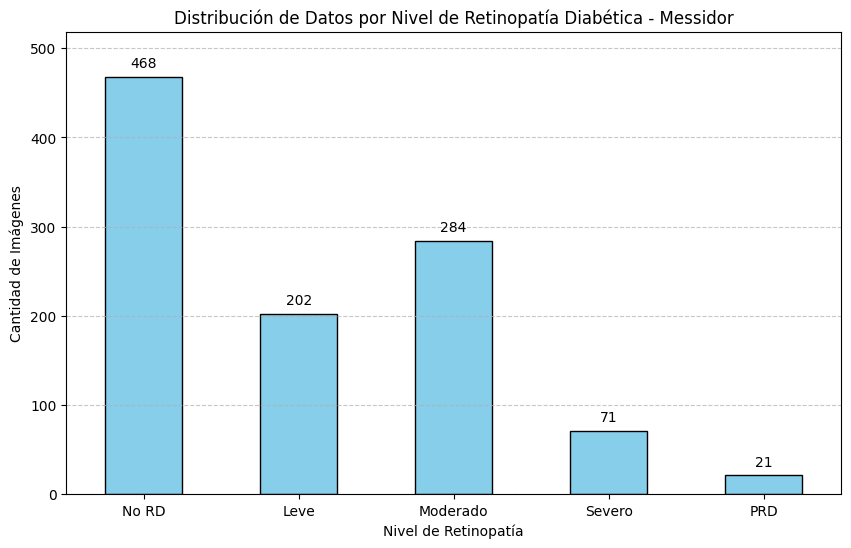

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Reemplaza la ruta de acceso con la ruta correcta que copiaste
# Asumo que estás usando el dataset que generó el gráfico más reciente (escala 0-500)
file_path = r'C:\Users\drive\OneDrive\Escritorio\data\datos_raw\messidor\train.csv'

try:
    # Carga el dataset
    df = pd.read_csv(file_path)

    # Cuenta las imágenes para cada nivel de retinopatía y ordena
    level_counts = df['level'].value_counts().sort_index()

    # --- AJUSTE CLAVE: RENOMBRAR LOS NIVELES ---
    # Diccionario para mapear los números (índice) a las etiquetas de texto
    level_map = {
        0: 'No RD',
        1: 'Leve',
        2: 'Moderado',
        3: 'Severo',
        4: 'PRD'
    }
    
    # Aplica el mapeo al índice de la serie de conteos
    level_counts = level_counts.rename(index=level_map)
    # ---------------------------------------------

    # Crea la figura y los ejes para el gráfico
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Genera el gráfico de barras y guarda las barras en una variable
    bars = level_counts.plot(kind='bar', color='skyblue', edgecolor='black', ax=ax)
    
    # --- Añadir las etiquetas de datos (números) sobre las barras ---
    # Desplazamiento adecuado para esta escala (0-500)
    VERTICAL_OFFSET = 7

    for bar in bars.patches:
        height = bar.get_height()
        x_pos = bar.get_x() + bar.get_width() / 2.0
        
        ax.text(
            x_pos, 
            height + VERTICAL_OFFSET, 
            f'{int(height)}',  
            ha='center', 
            va='bottom',
        )
    # ------------------------------------------------------------------

    # Configuración del gráfico
    # También actualizaremos el título para reflejar que es el dataset Messidor
    ax.set_title('Distribución de Datos por Nivel de Retinopatía Diabética - Messidor')
    ax.set_xlabel('Nivel de Retinopatía')
    ax.set_ylabel('Cantidad de Imágenes')
    
    # Asegura que las etiquetas de texto (No DR, Mild, etc.) se vean horizontales
    plt.xticks(rotation=0) 
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Ajusta el límite superior del eje Y
    y_max = level_counts.max()
    ax.set_ylim(top=y_max + 50) 
    
    # Guarda y muestra el gráfico
    plt.savefig('distribucion_niveles_etiquetas_texto.png')
    plt.show()
    
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta '{file_path}'. Por favor, verifica la ruta de acceso.")
